In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colormaps

In [18]:
for color in list(colormaps):
    print(f"{color}", end=" ") #´     

magma inferno plasma viridis cividis twilight twilight_shifted turbo berlin managua vanimo Blues BrBG BuGn BuPu CMRmap GnBu Greens Greys OrRd Oranges PRGn PiYG PuBu PuBuGn PuOr PuRd Purples RdBu RdGy RdPu RdYlBu RdYlGn Reds Spectral Wistia YlGn YlGnBu YlOrBr YlOrRd afmhot autumn binary bone brg bwr cool coolwarm copper cubehelix flag gist_earth gist_gray gist_heat gist_ncar gist_rainbow gist_stern gist_yarg gnuplot gnuplot2 gray hot hsv jet nipy_spectral ocean pink prism rainbow seismic spring summer terrain winter Accent Dark2 Paired Pastel1 Pastel2 Set1 Set2 Set3 tab10 tab20 tab20b tab20c grey gist_grey gist_yerg Grays magma_r inferno_r plasma_r viridis_r cividis_r twilight_r twilight_shifted_r turbo_r berlin_r managua_r vanimo_r Blues_r BrBG_r BuGn_r BuPu_r CMRmap_r GnBu_r Greens_r Greys_r OrRd_r Oranges_r PRGn_r PiYG_r PuBu_r PuBuGn_r PuOr_r PuRd_r Purples_r RdBu_r RdGy_r RdPu_r RdYlBu_r RdYlGn_r Reds_r Spectral_r Wistia_r YlGn_r YlGnBu_r YlOrBr_r YlOrRd_r afmhot_r autumn_r binary_

In [5]:
df = pd.read_csv('./data/titanic.csv')
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
684,685,0,2,"Brown, Mr. Thomas William Solomon",male,60.0,1,1,29750,39.0000,NaN,S
336,337,0,1,"Pears, Mr. Thomas Clinton",male,29.0,1,0,113776,66.6000,C2,S
876,877,0,3,"Gustafsson, Mr. Alfred Ossian",male,20.0,0,0,7534,9.8458,NaN,S
488,489,0,3,"Somerton, Mr. Francis William",male,30.0,0,0,A.5. 18509,8.0500,NaN,S
804,805,1,3,"Hedman, Mr. Oskar Arvid",male,27.0,0,0,347089,6.9750,NaN,S


In [8]:
print(f"El shape del conjunto de entrenamiento es {df.shape}. {df.shape[0]} filas y {df.shape[1]} columnas.") 

El shape del conjunto de entrenamiento es (891, 12). 891 filas y 12 columnas.


Para obtener la información del dataframe

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


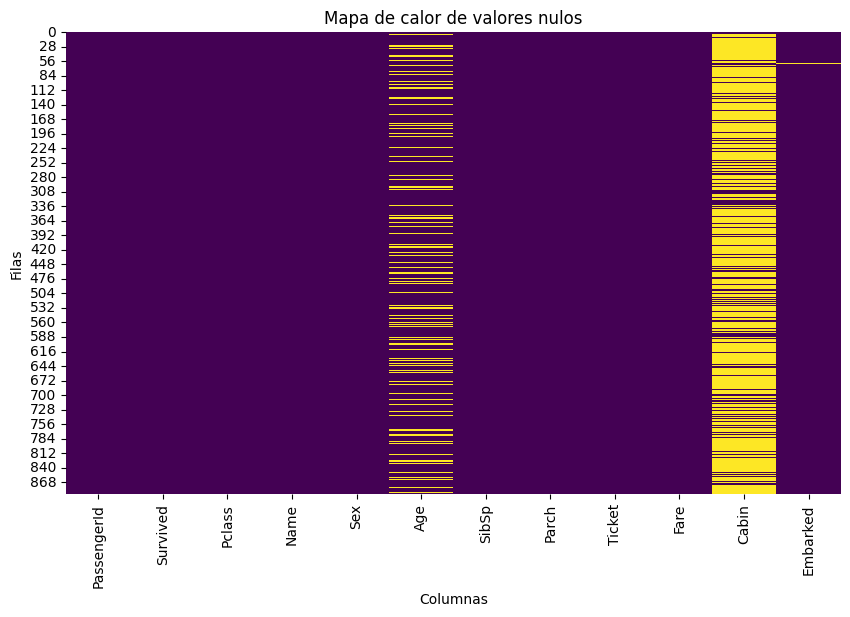

In [12]:
# Mapa de calor de valores nulos
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

plt.title('Mapa de calor de valores nulos')
plt.xlabel('Columnas')
plt.ylabel('Filas')

plt.show()

In [13]:
missing_values_percentage = df.isnull().mean() * 100
missing_values_percentage = missing_values_percentage.round(2).sort_values(ascending=False)
print(missing_values_percentage)

Cabin          77.10
Age            19.87
Embarked        0.22
PassengerId     0.00
Name            0.00
Pclass          0.00
Survived        0.00
Sex             0.00
Parch           0.00
SibSp           0.00
Fare            0.00
Ticket          0.00
dtype: float64


/tmp/ipykernel_83358/1228927709.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


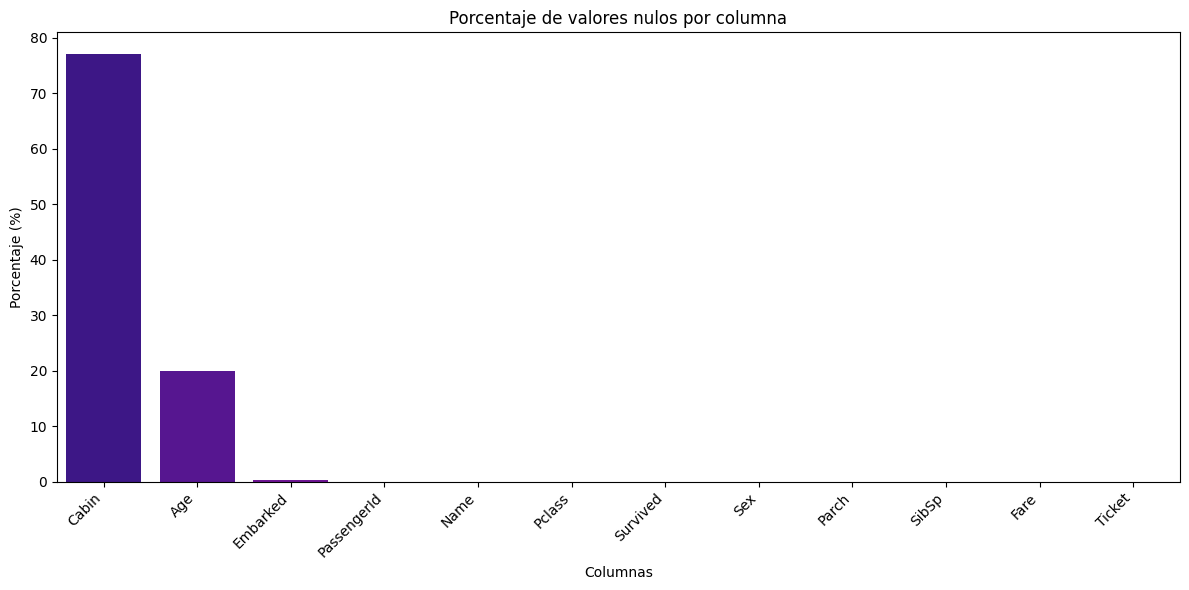

In [19]:
# Configurar figura
plt.figure(figsize=(12,6))

# Crear gráfica de barras
sns.barplot(
    x=missing_values_percentage.index,
    y=missing_values_percentage.values,
    palette='plasma'
)

# Personalización
plt.title('Porcentaje de valores nulos por columna')
plt.xlabel('Columnas')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

Esta línea solo se puede utilizar una vez porque, una vez borrado 'Cabin', marca error si queremos eliminar algo que ya no esxite.

In [ ]:
df.drop('Cabin', axis=1, inplace=True)

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 76.7 KB


In [31]:
# Rellenar valores nulos de Age con la mediana
df['Age'] = df['Age'].fillna(df['Age'].median())

In [32]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [33]:
round(df.isnull().sum().sort_values(ascending = False) / len(df) * 100, 2)

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df.drop('Name', axis = 1, inplace = True)
df.drop('Ticket', axis = 1, inplace = True)
df.drop('PassengerId', axis = 1, inplace = True)

In [36]:
print(f"Después de limpiar df: {df.shape[0]} filas y {df.shape[1]} columnas.")

Después de limpiar df: 891 filas y 8 columnas.


In [37]:
df.to_csv('./data/titanic_clean.csv', index=False)